<a href="https://colab.research.google.com/github/ABDarif/pdf_analyzer/blob/main/CSE422_Section1_LabProject_MehnajMissal_AbdullahArif_Spring'24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Collection

In [ ]:
# installing kaggle library

! pip install kaggle

In [ ]:
# UPLOAD KAGGLE.json FILE

# configuring the path of kaggle.json file

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# IMPORTING TWITTER SENTIMENT DATASET

# api to fetch the dataset from kaggle

!kaggle datasets download -d abhi8923shriv/sentiment-analysis-dataset

 96% 52.0M/54.4M [00:00<00:00, 104MB/s] 
100% 54.4M/54.4M [00:00<00:00, 91.7MB/s]


In [ ]:
# extracting the compressed dataset

from zipfile import ZipFile
dataset = '/content/sentiment-analysis-dataset.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print("The dataset is extracted")

The dataset is extracted


In [ ]:
# IMPORTING THE DEPENDENCIES

# utilities
import re # regular expression
import numpy as np
import pandas as pd

# nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer # reduce the words to it's root words. Ex: actor, actress -> act

# sklearn
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.validation import check_array

# plotting
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# printing stopwords in english

print(stopwords.words('english'))

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

Data Processing

In [ ]:
# loading the data from csv to pandas dataframe

twitter_data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding = 'ISO-8859-1')

In [ ]:
# checking the number of rows & columns

twitter_data.shape

(1048572, 6)

In [ ]:
# printing first 5 rows of the dataframe

twitter_data.head()

,polarity of tweet,id of the tweet,date of the tweet,query,user,text of the tweet
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
twitter_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048572 entries, 0 to 1048571
Data columns (total 6 columns):
 #   Column              Non-Null Count    Dtype 
---  ------              --------------    ----- 
 0   polarity of tweet   1048572 non-null  int64 
 1   id of the tweet     1048572 non-null  int64 
 2   date of the tweet   1048572 non-null  object
 3   query               1048572 non-null  object
 4   user                1048572 non-null  object
 5   text of the tweet   1048572 non-null  object
dtypes: int64(2), object(4)
memory usage: 48.0+ MB


In [ ]:
twitter_data.describe()

,polarity of tweet,id of the tweet
count,1.048572e+06,1.048572e+06
mean,2.370615e-01,1.976168e+09
std,4.252805e-01,2.300567e+08
min,0.000000e+00,1.467811e+09
25%,0.000000e+00,1.824526e+09
50%,0.000000e+00,1.990870e+09
75%,0.000000e+00,2.198903e+09
max,1.000000e+00,2.329206e+09


from matplotlib import pyplot as plt
_df_0['polarity of tweet\xa0'].plot(kind='hist', bins=20, title='polarity of tweet\xa0')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['id of the tweet'].plot(kind='hist', bins=20, title='id of the tweet')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='polarity of tweet\xa0', y='id of the tweet', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['polarity of tweet\xa0'].plot(kind='line', figsize=(8, 4), title='polarity of tweet\xa0')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_4['id of the tweet'].plot(kind='line', figsize=(8, 4), title='id of the tweet')
plt.gca().spines[['top', 'right']].set_visible(False)

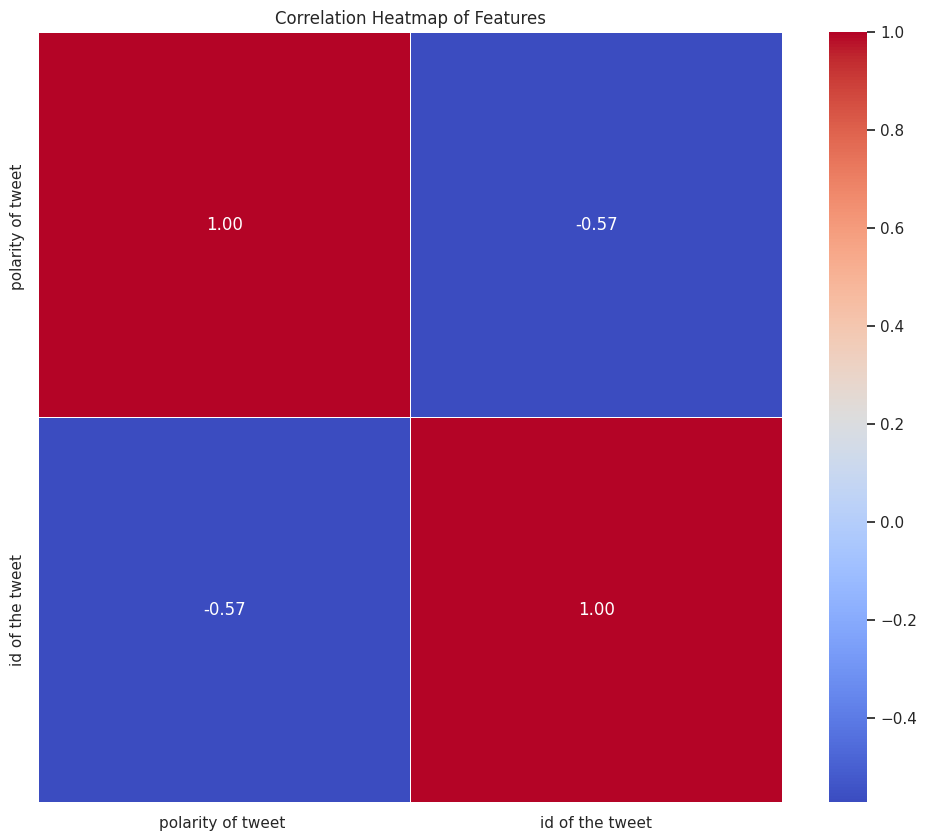

In [ ]:
# Select only numeric columns
numeric_data = twitter_data.select_dtypes(include=['float64', 'int64'])

# Compute correlation
corr = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

In [ ]:
# counting the number of missing values in the dataset

twitter_data.isnull().sum()

polarity of tweet     0
id of the tweet       0
date of the tweet     0
query                 0
user                  0
text of the tweet     0
dtype: int64

In [ ]:
# checking the distribution of polarity of tweet column

twitter_data['polarity of tweet\xa0'].value_counts()

polarity of tweet 
0    799996
4    248576
Name: count, dtype: int64

In [ ]:
# convert the target "4" to "1"

twitter_data.replace({'polarity of tweet\xa0': {4:1}}, inplace=True)

In [ ]:
# HANDLING THE IMBALANCED DATASET

# install imbalanced-learn

! pip install -U imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 2.0 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.10.1
    Uninstalling imbalanced-learn-0.10.1:
      Successfully uninstalled imbalanced-learn-0.10.1


In [ ]:
# split the dataset from the dataframe

x = twitter_data.drop(['polarity of tweet\xa0'], axis=1)
y = twitter_data['polarity of tweet\xa0']

In [ ]:
y.value_counts()

polarity of tweet 
0    799996
1    248576
Name: count, dtype: int64

<Axes: xlabel='polarity of tweet\xa0'>

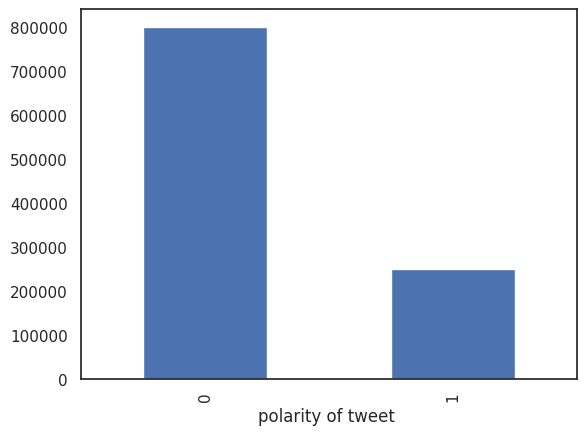

In [ ]:
y.value_counts().plot.bar()

<Axes: ylabel='count'>

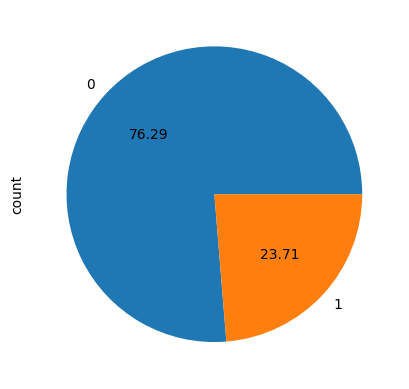

In [ ]:
y.value_counts().plot.pie(autopct='%.2f')

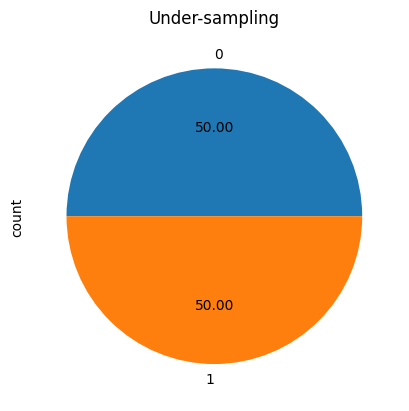

In [ ]:
# random undersampling

from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy=1)
X_res, Y_res = rus.fit_resample(x, y)

ax = Y_res.value_counts().plot.pie(autopct='%.2f')
_ = ax.set_title("Under-sampling")

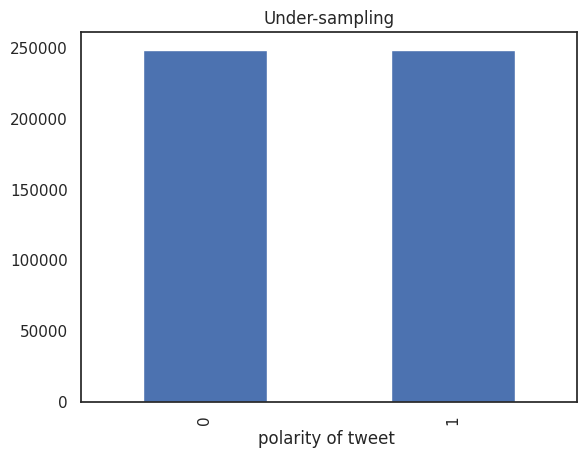

In [ ]:
ax = Y_res.value_counts().plot.bar()
_ = ax.set_title("Under-sampling")

In [ ]:
Y_res.value_counts()

polarity of tweet 
0    248576
1    248576
Name: count, dtype: int64

STEMMING

In [ ]:
port_stem = PorterStemmer()

In [ ]:
def stemming(content):
  stemmed_content = re.sub('[^a-zA-Z]', ' ', content)
  stemmed_content = stemmed_content.lower()
  stemmed_content = stemmed_content.split()
  stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
  stemmed_content = ' '.join(stemmed_content)

  return stemmed_content

In [ ]:
X_res['stemmed_content'] = X_res['text of the tweet\xa0'].apply(stemming)

In [ ]:
X_res.head()

,id of the tweet,date of the tweet,query,user,text of the tweet,stemmed_content
762622,2297982793,Tue Jun 23 11:06:42 PDT 2009,NO_QUERY,ProminentlyPosh,"@jazzygladly well since she's OK, I'm gonna ki...",jazzygladli well sinc ok gonna kick ass scare ...
392121,2055072458,Sat Jun 06 08:38:45 PDT 2009,NO_QUERY,Sherixoxo,@jojoiskingswag me and @skyetunes tried #SF Se...,jojoiskingswag skyetun tri sf sexi friend satu...
703502,2255725121,Sat Jun 20 11:41:42 PDT 2009,NO_QUERY,daniirwan,wonders how he can survive next month with so ...,wonder surviv next month littl money n mani need
715673,2259488316,Sat Jun 20 17:40:02 PDT 2009,NO_QUERY,beetlebum_,@dmeeno i payed a tenner to get into a club th...,dmeeno pay tenner get club sell grolsch im eve...
499408,2186521002,Mon Jun 15 18:57:36 PDT 2009,NO_QUERY,Dodio,@LeannSoto pictures please because OMG that so...,leannsoto pictur pleas omg sound amaz damn dam...


In [ ]:
print(X_res['stemmed_content'])

762622     jazzygladli well sinc ok gonna kick ass scare ...
392121     jojoiskingswag skyetun tri sf sexi friend satu...
703502      wonder surviv next month littl money n mani need
715673     dmeeno pay tenner get club sell grolsch im eve...
499408     leannsoto pictur pleas omg sound amaz damn dam...
                                 ...                        
1048567                              grandma make dinenr mum
1048568             mid morn snack time bowl chees noodl yum
1048569         shadela say like termini movi come like word
1048570                      destinyhop im great thaank wbuu
1048571                           cant wait til date weekend
Name: stemmed_content, Length: 497152, dtype: object


In [ ]:
Y_res.values

array([0, 0, 0, ..., 1, 1, 1])

In [ ]:
# separating the data & label

X = X_res['stemmed_content'].values
Y = Y_res.values

In [ ]:
print(X)

['jazzygladli well sinc ok gonna kick ass scare shit outta know go'
 'jojoiskingswag skyetun tri sf sexi friend saturday seem everyon cool let c ss work'
 'wonder surviv next month littl money n mani need' ...
 'shadela say like termini movi come like word'
 'destinyhop im great thaank wbuu' 'cant wait til date weekend']


In [ ]:
print(Y)

[0 0 0 ... 1 1 1]


SPLITTING THE DATA TO TRAINING DATA & TEST DATA

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, stratify = Y, random_state = 2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(497152,) (348006,) (149146,)


FEATURE EXTRACTION

In [ ]:
# converting the textual data to numerical data

vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [ ]:
print(X_train)

  (0, 164109)	0.31065963492312804
  (0, 9584)	0.9505212208201502
  (1, 64129)	0.3584542902638715
  (1, 18691)	0.5226152015992774
  (1, 99495)	0.3041146577376007
  (1, 93376)	0.7112651740370202
  (2, 49953)	0.42619238135204784
  (2, 93188)	0.2852134797550682
  (2, 179130)	0.27855110752679335
  (2, 65082)	0.29845940003378113
  (2, 78207)	0.7552116207200127
  (3, 82700)	0.35620560351324454
  (3, 32333)	0.24358752478399995
  (3, 32301)	0.2265925165836645
  (3, 167823)	0.31765796300404087
  (3, 70846)	0.2109368888790824
  (3, 52381)	0.3476762491058468
  (3, 62710)	0.2208361819972406
  (3, 27311)	0.6688723130780337
  (4, 11281)	0.5121620854296366
  (4, 129172)	0.3382318596179234
  (4, 62194)	0.5319712889247482
  (4, 146719)	0.4859254695991679
  (4, 144954)	0.3227571736496914
  (5, 108913)	0.25291210497701705
  :	:
  (348002, 27304)	0.22796019538639645
  (348002, 56506)	0.22439528452481844
  (348002, 6061)	0.16674143754058735
  (348002, 172464)	0.1704438187210203
  (348002, 182914)	0.14161892

In [ ]:
print(X_test)

  (0, 182914)	0.2082552129566277
  (0, 154208)	0.27105259340875526
  (0, 150853)	0.6702179553132838
  (0, 120339)	0.3165508107544686
  (0, 113875)	0.2542415452940259
  (0, 51744)	0.3925644219747262
  (0, 41879)	0.33914325249856025
  (1, 183084)	0.35951245531812576
  (1, 180043)	0.22886850378748805
  (1, 166315)	0.2206332323562544
  (1, 126223)	0.33176437667940206
  (1, 79080)	0.6469134158437494
  (1, 45072)	0.31754308507288037
  (1, 43405)	0.3745568035899727
  (2, 164109)	0.457742239740622
  (2, 61341)	0.6432769293909824
  (2, 49622)	0.6137318910326789
  (3, 130022)	0.3209376067315456
  (3, 123154)	0.4432389644570514
  (3, 117832)	0.27640612588557045
  (3, 90299)	0.22341023784008684
  (3, 82133)	0.6635062737462514
  (3, 58048)	0.25681604318034446
  (3, 55926)	0.26082702474665154
  (4, 179331)	0.2487296884790113
  :	:
  (149143, 168440)	0.16460791408461095
  (149143, 167379)	0.27424564224351294
  (149143, 166816)	0.28740890369930083
  (149143, 166315)	0.1762732727990018
  (149143, 15773

TRAINING THE MACHINE LEARNING MODEL

Logistic Regression

Logistic Regression Accuracy: 0.7749
Logistic Regression Precision: 0.7753
Logistic Regression Recall: 0.7749
Logistic Regression F1-Score: 0.7748


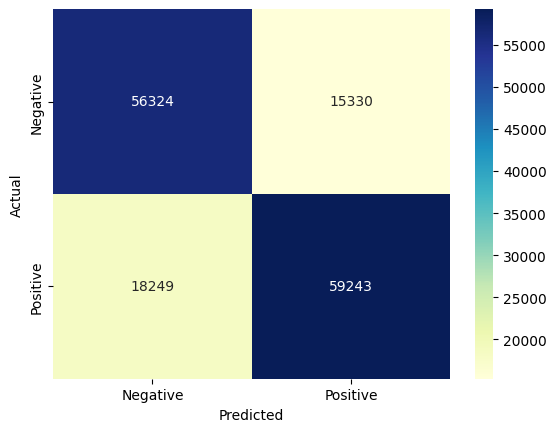

In [ ]:
logmodel = LogisticRegression(max_iter=1000000, random_state=42)
logmodel.fit(X_train, Y_train)

# Predict labels on the train & test set
y_test_pred = logmodel.predict(X_test)

# Calculate logistic regression metrics
lr_accuracy_test = accuracy_score(Y_test, y_test_pred)
lr_precision = precision_score(Y_test, y_test_pred,average='weighted')
lr_recall = recall_score(Y_test, y_test_pred,average='weighted')
lr_f1 = f1_score(Y_test, y_test_pred,average='weighted')

print(f"Logistic Regression Accuracy: {lr_accuracy_test:.4f}")
print(f"Logistic Regression Precision: {lr_precision:.4f}")
print(f"Logistic Regression Recall: {lr_recall:.4f}")
print(f"Logistic Regression F1-Score: {lr_f1:.4f}")

conf = confusion_matrix(y_test_pred, Y_test)
sns.heatmap(conf , cmap='YlGnBu', fmt='', xticklabels=['Negative' ,'Positive'], yticklabels=['Negative' ,'Positive'], annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Linear Regression

Linear Regression Accuracy (test): 0.7373
Linear Regression Precision: 0.7374
Linear Regression Recall: 0.7373
Linear Regression F1-Score: 0.7372


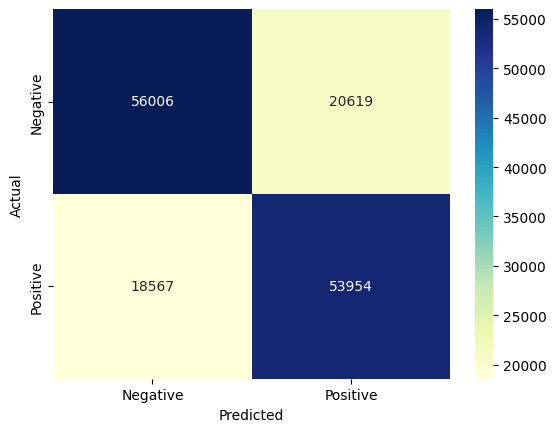

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

linmodel = LinearRegression()
linmodel.fit(X_train, Y_train)
y_train_pred = linmodel.predict(X_train)
y_pred = linmodel.predict(X_test)

threshold = 0.5  # Example threshold for binary classification
y_pred_binary = [1 if pred >= threshold else 0 for pred in y_pred]

linmodel_accuracy_test = accuracy_score(Y_test, y_pred_binary)
linmodel_precision = precision_score(Y_test, y_pred_binary,average='weighted')
linmodel_recall = recall_score(Y_test, y_pred_binary,average='weighted')
linmodel_f1 = f1_score(Y_test, y_pred_binary,average='weighted')

print(f"Linear Regression Accuracy (test): {linmodel_accuracy_test:.4f}")
print(f"Linear Regression Precision: {linmodel_precision:.4f}")
print(f"Linear Regression Recall: {linmodel_recall:.4f}")
print(f"Linear Regression F1-Score: {linmodel_f1:.4f}")

conf = confusion_matrix(y_pred_binary, Y_test)
sns.heatmap(conf , cmap='YlGnBu', fmt='', xticklabels=['Negative' ,'Positive'], yticklabels=['Negative' ,'Positive'], annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree

Decision Tree Accuracy (test): 0.7007
Decision Tree Precision: 0.7008
Decision Tree Recall: 0.7007
Decision Tree F1-Score: 0.7006


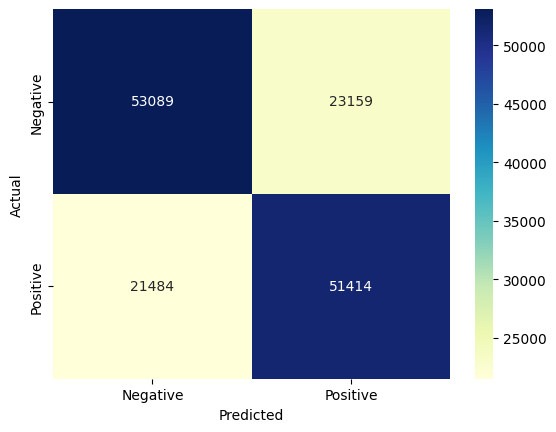

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

DT_model = DecisionTreeClassifier()
DT_model.fit(X_train, Y_train)
y_pred = DT_model.predict(X_test)

DTmodel_accuracy_test = accuracy_score(Y_test, y_pred)
DTmodel_precision = precision_score(Y_test, y_pred,average='weighted')
DTmodel_recall = recall_score(Y_test, y_pred,average='weighted')
DTmodel_f1 = f1_score(Y_test, y_pred,average='weighted')

print(f"Decision Tree Accuracy (test): {DTmodel_accuracy_test:.4f}")
print(f"Decision Tree Precision: {DTmodel_precision:.4f}")
print(f"Decision Tree Recall: {DTmodel_recall:.4f}")
print(f"Decision Tree F1-Score: {DTmodel_f1:.4f}")

conf = confusion_matrix(y_pred, Y_test)
sns.heatmap(conf , cmap='YlGnBu', fmt='', xticklabels=['Negative' ,'Positive'], yticklabels=['Negative' ,'Positive'], annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

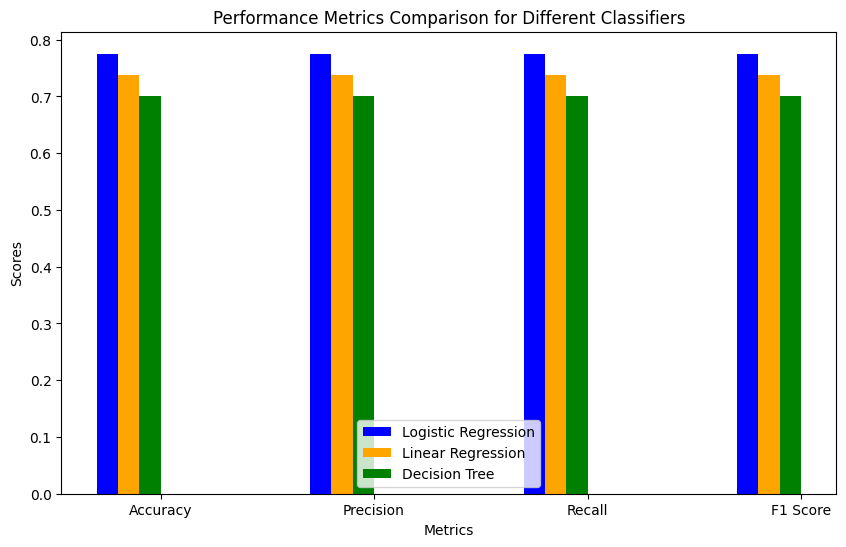

In [ ]:
#classifiers and their colors
classifiers = ['Logistic Regression', 'Linear Regression', 'Decision Tree']
colors = ['blue', 'orange', 'green']

# metric scores
accuracy_scores = [lr_accuracy_test, linmodel_accuracy_test, DTmodel_accuracy_test]
precision_scores = [lr_precision, linmodel_precision, DTmodel_precision]
recall_scores = [lr_recall, linmodel_recall, DTmodel_recall]
f1_scores = [lr_f1, linmodel_f1, DTmodel_f1]

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Define the data for each metric
data = [accuracy_scores, precision_scores, recall_scores, f1_scores]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(metrics))

# Set the width of each bar
width = 0.10

#each classifier and plot bars
for i, classifier in enumerate(classifiers):
    ax.bar(x + i*width, [d[i] for d in data], width, label=classifier, color=colors[i])

#labels, title, and legend
ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Performance Metrics Comparison for Different Classifiers')
ax.set_xticks(x + 2.5*width)
ax.set_xticklabels(metrics)
ax.legend()

# Show the plot
plt.show()

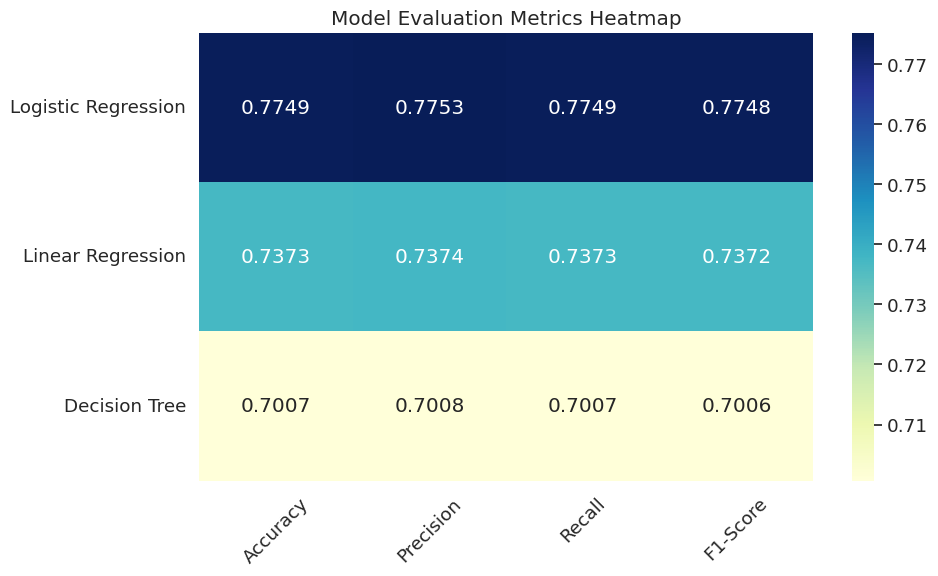

In [ ]:
#classifiers and metrics
classifiers = ['Logistic Regression', 'Linear Regression', 'Decision Tree']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# metric scores
accuracy_scores = [lr_accuracy_test, linmodel_accuracy_test, DTmodel_accuracy_test]
precision_scores = [lr_precision, linmodel_precision, DTmodel_precision]
recall_scores = [lr_recall, linmodel_recall, DTmodel_recall]
f1_scores = [lr_f1, linmodel_f1, DTmodel_f1]

#dictionary to store metric
metric_scores = {
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
}

#DataFrame from the dictionary
df = pd.DataFrame(metric_scores, index=classifiers)

#heatmap
plt.figure(figsize=(10, 6))
sns.set(font_scale=1.2)
sns.heatmap(df, annot=True, cmap='YlGnBu', fmt='.4f')
plt.title("Model Evaluation Metrics Heatmap")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
df

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.774858,0.775280,0.774858,0.774772
Linear Regression,0.737264,0.737444,0.737264,0.737214
Decision Tree,0.700676,0.700777,0.700676,0.700638
